<small><font color=gray>Авторы ноутбука: Олег Мельников, Кирилл Быков, Алексей Болдырев, Максим Карпов, Юрий Саночкин ©2026 </font></small><hr style="margin:0;background-color:silver">

**[<font size=6>🪐Venus+Mars</font>](https://www.kaggle.com/t/022c879ccb9a45ce9a80c46225c8627e)**.

In [1]:
from google.colab import drive; drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%%capture
pip install -U kaggle  # upgrade пакет kaggle (чтобы избежать предупреждения)

In [3]:
!mkdir -p ~/.kaggle                               # папка .kaggle должна содержать kaggle.json для исполняемого файла kaggle, чтобы правильно аутентифицировать вас в Kaggle.com
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/kaggle.json  # Сначала загрузите kaggle.json из kaggle.com (на странице учетной записи) и поместите его в корень подключенного Google Диска
!chmod 600 ~/.kaggle/kaggle.json                  # предоставить только владельцу полный доступ для чтения/записи к файлу kaggle.json
!kaggle config set -n competition -v june-26-hse-bi-venus-mars # установите контекст конкурса для следующих нескольких вызовов API kaggle. !kaggle config view - отображает текущие настройки
!kaggle competitions download                     # загрузите набор данных соревнования в виде zip-файла
!unzip -o *.zip                                   # набор данных с kaggle копируется в виде единого файла, который необходимо распаковать
!kaggle competitions leaderboard --show           # напечатать public leaderboard

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: train/female/fx103b1.jpg  
  inflating: train/female/fx103c4.jpg  
  inflating: train/female/fx103eb.jpg  
  inflating: train/female/fx103ee.jpg  
  inflating: train/female/fx104cf.jpg  
  inflating: train/female/fx104d6.jpg  
  inflating: train/female/fx104d7.jpg  
  inflating: train/female/fx104dd.jpg  
  inflating: train/female/fx1051d.jpg  
  inflating: train/female/fx1055d.jpg  
  inflating: train/female/fx105b2.jpg  
  inflating: train/female/fx105b9.jpg  
  inflating: train/female/fx105e7.jpg  
  inflating: train/female/fx105f1.jpg  
  inflating: train/female/fx10637.jpg  
  inflating: train/female/fx10675.jpg  
  inflating: train/female/fx1067f.jpg  
  inflating: train/female/fx10685.jpg  
  inflating: train/female/fx1068f.jpg  
  inflating: train/female/fx106c4.jpg  
  inflating: train/female/fx10742.jpg  
  inflating: train/female/fx10826.jpg  
  inflating: train/female/fx10830.jpg  
  inflating:

Смотрите [больше](https://nvidia.custhelp.com/app/answers/detail/a_id/3751/~/useful-nvidia-smi-queries) про NVIDIA GPU статистику. Тестируйте свой код в бесплатном Colab. В нем используется графический процессор Tesla T4 или TPU v2-8.

In [4]:
!nvidia-smi --query-gpu=gpu_name,memory.total,memory.free,memory.used --format=csv

name, memory.total [MiB], memory.free [MiB], memory.used [MiB]
Tesla T4, 15360 MiB, 14913 MiB, 0 MiB


In [5]:
%%time
%%capture
%reset -f
from IPython.core.interactiveshell import InteractiveShell as IS; IS.ast_node_interactivity = "all"
import numpy as np, pandas as pd, time, matplotlib.pyplot as plt, os
from torch.utils.data import random_split
import torch, torchvision
from torch.utils.data import DataLoader
from torch import nn
from torch.nn import Sequential, Flatten, Linear, LazyLinear, Dropout, AdaptiveAvgPool2d, MaxPool2d, Conv2d, AvgPool2d
import torchvision
from torchvision.models import resnet50, mobilenet_v2, mobilenet_v3_small
from torchvision.datasets import ImageFolder
import torchvision.transforms as v2
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)
ToCSV = lambda df, fname: df.round(2).to_csv(f'{fname}.csv', index_label='id') # округляет значения до 2 знаков после точки

class Timer():
  def __init__(self, lim:'RunTimeLimit'=60*5): self.t0, self.lim, _ = time.time(), lim, print(f'⏳ начался. У вас есть {lim} сек. Удачи!')
  def ShowTime(self):
    msg = f'Время выполнения {time.time()-self.t0:.0f} сек.'
    print(f'\033[91m\033[1m' + msg + f' > {self.lim} sec limit!!!\033[0m' if (time.time()-self.t0-1) > self.lim else msg)

np.set_printoptions(linewidth=100, precision=2, edgeitems=5, suppress=True)
pd.set_option('display.max_columns', 20, 'display.precision', 2, 'display.max_rows', 4)
tDIR, sDIR = 'train/', 'test/'

CPU times: user 3.92 s, sys: 529 ms, total: 4.45 s
Wall time: 5.68 s


Примеры изображений женского пола

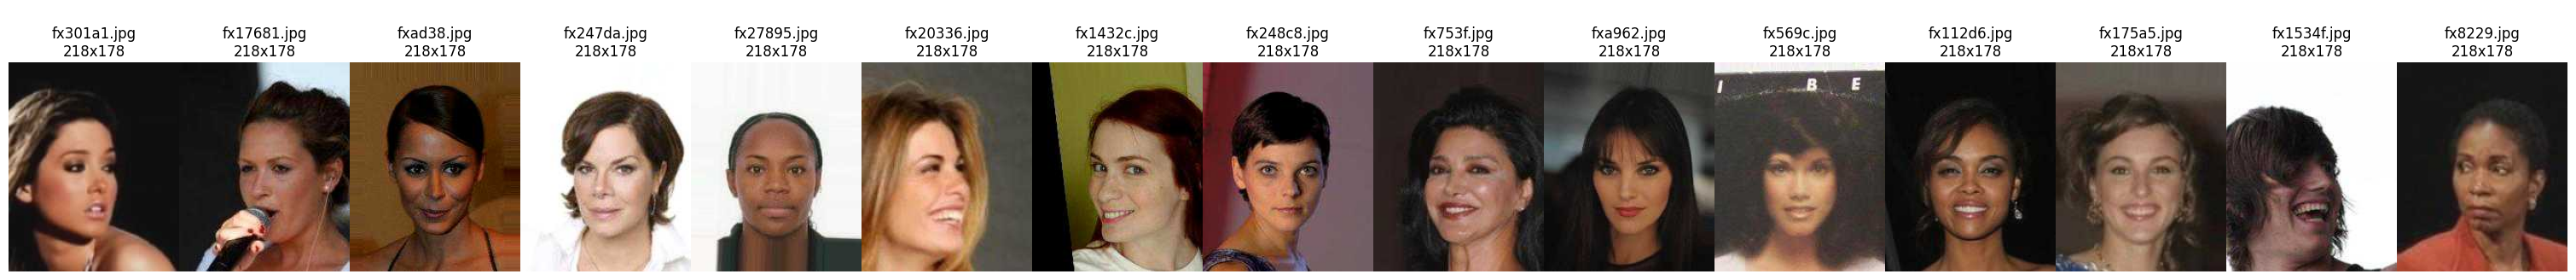

In [6]:
n, fig = 15, plt.figure(figsize=(30,10));
for i, f in enumerate(np.random.RandomState(0).choice(os.listdir(tDIR+'female/'), n)):
  ax = plt.subplot(1, n, i + 1)
  img = plt.imread(tDIR+'female/'+f);
  _ = ax.set_title(f'\n{f}\n{img.shape[0]}x{img.shape[1]}');
  _ = plt.axis('off');   _ = plt.tight_layout(pad=0);   _ = plt.imshow(img);

Примеры изображений мужского пола

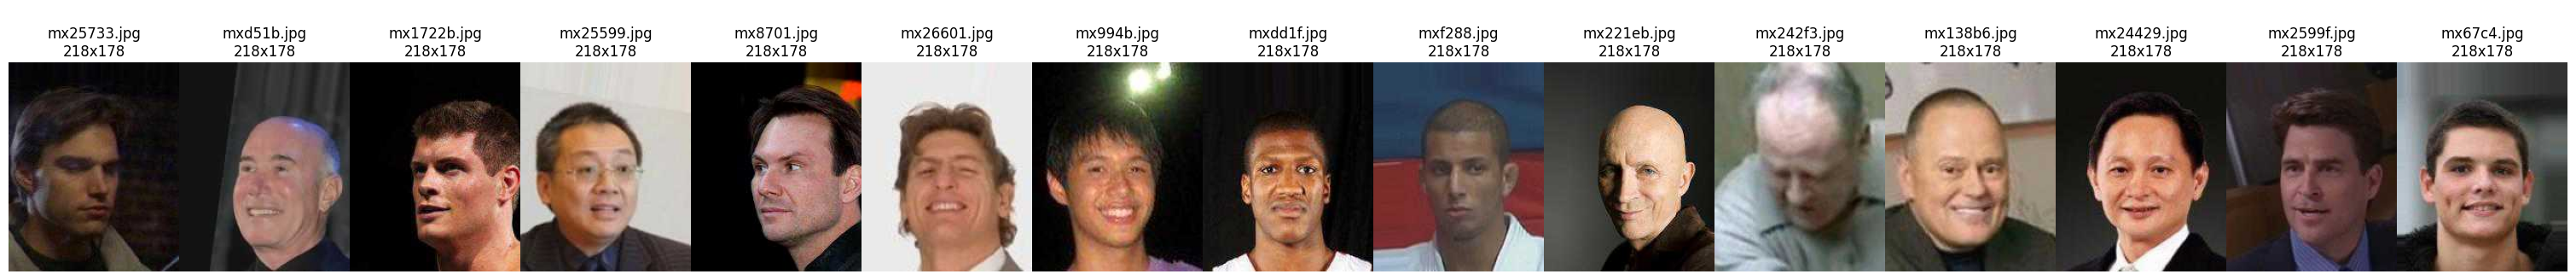

In [7]:
n, fig = 15, plt.figure(figsize=(30,10));
for i, f in enumerate(np.random.RandomState(0).choice(os.listdir(tDIR+'male/'), n)):
  ax = plt.subplot(1, n, i + 1)
  img = plt.imread(tDIR+'male/'+f);
  _ = ax.set_title(f'\n{f}\n{img.shape[0]}x{img.shape[1]}');
  _ = plt.axis('off');   _ = plt.tight_layout(pad=0);   _ = plt.imshow(img);

<font size=5>⏳</font> <strong><font color=orange size=5>Ваш код, документация, идеи и таймер - Все это начинается здесь...</font></strong>


## **Задание 1**

**Объясните вашу предобработку данных:** например, feature engineering, subsampling, кластеризация, снижение размерности и т.д.

Картинок немного и они лёгкие, поэтому ничего не выкидываю. Каждую картинку привожу ко входу предобученной сети: ресайз, обрезка до 224×224 и нормировка по средним/стандартам ImageNet (как в семинаре 18-19) — без неё предобученная сеть работает хуже.

На обучении добавляю простую аугментацию: случайную обрезку и горизонтальное отражение, чтобы модель меньше переобучалась. На валидации и тесте аугментаций нет (только ресайз и центральная обрезка) — там надо проверять на «настоящих» картинках.

Руками признаки не конструирую — их выделит сама свёрточная сеть.

In [8]:
tmr = Timer() # время выполнения (в секундах)

⏳ начался. У вас есть 300 сек. Удачи!


## **Задание 2**

**Объясните свой подход к построению модели:** идеи, которые вы попробовали, и почему вы решили, что они будут полезны. Вывод: как эти решения помогали вам в моделировании.

Беру transfer learning из семинара 18-19, вариант «дообучение» (fine-tuning): предобученная на ImageNet, так как она уже умеет выделять черты лица, остаётся подстроить её под задачу бинарной классификации.

Сначала я брал предобученный MobileNetV2 и менял верхний слой-классификатор на новый линейный с 2 классами и дообучаю сеть целиком обычным циклом обучения. Для нее я брал функцию потреь (CrossEntropyLoss), оптимизатор (Adam) с небольшим lr=1e-4 и расписание StepLR (потом убрал его).

Почему так взял:
- замороженные слои давали не сильно хорошее качество
- lr маленький (1e-4), потому что сеть уже почти обучена её надо лишь аккуратно подвинуть
- аугментацию делал как в семинаре, но картинки я не брал квадратные, так как форма лица все таки не квадратная и должна быть высота больше ширины.

Как подобрал размер пропорции картинки:  оставил 224 (как привык MobileNet), а ширину подобрал под пропорции самих изначальных фоток 178 * 218 (178/218 около 0.82): 224 * 0.82 = 184, чтобы лицо не сплющивалось.

Ниже грузим картинки через ImageFolder, делим трейн на обучение и валидацию (85/15) и заворачиваем в DataLoader, аугментации применял только к обучающей части

In [9]:
import random

#фиксация seed
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [10]:
BS = 32
train_tf = v2.Compose([
    v2.Resize((256, 208)),
    v2.RandomCrop((224, 184)),
    v2.RandomHorizontalFlip(),
    v2.ToTensor(),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
eval_tf = v2.Compose([
    v2.Resize((256, 208)),
    v2.CenterCrop((224, 184)),
    v2.ToTensor(),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

In [12]:
# На трейне нужно сделать аугментацию (а на тесте нет)
im_folder_train = ImageFolder(tDIR, transform=train_tf)
im_folder_test = ImageFolder(sDIR, transform=eval_tf)
print('классы:', im_folder_train.classes)

классы: ['female', 'male']


In [13]:
#Делим train на обучение и валидацию 85/15 (так вышло лучше качество )
tDS, vDS = random_split(im_folder_train, lengths=[0.85, 0.15])

In [14]:
# на трейне перемешиваем, на валидации и тесте нет
tDL = DataLoader(tDS, batch_size=BS, shuffle=True, pin_memory=True)
vDL = DataLoader(vDS, batch_size=BS, shuffle=False, pin_memory=True)
sDL = DataLoader(im_folder_test, batch_size=BS, shuffle=False, pin_memory=True)

In [15]:
print('train:', len(tDS), '| val:', len(vDS), '| test:', len(im_folder_test))

train: 4250 | val: 750 | test: 5000


### Дообучение предобученной сети (fine-tuning, семинар 18-19)

Начал с MobileNetV2 с весами ImageNet и поменял верхний класификатор на линейный с выходом на 2 класса и дообучал всю сеть функцией train_model, как в семинаре (фазы train/val, argmax для предсказания, шаг scheduler после трейна).

Дальше перебирал learning rate и расписание:
- без scheduler, lr=1e-4 - лучшая val вышла ~0.94;
- lr=1e-3 (scheduler шаг 2, гамма 0.1) тут валидация упала до 0.91
- lr=1e-5 (scheduler шаг 2) - снова ниже около 0.918


Потом взял ResNet18 и повторил то же самое, поскольку я брал без sheduler , то на 5 эпохах у меня вылетало переобучение в хвосте и на 3 эпохе было качество 0.95 а потом резко падало до 0.93, а трейн выростал и тут sheduler очень сильно помог. Я взял StepLR с шагом 3 и он держит lr=1e-4 первые 3 эпохи, а на последних двух роняет до 1e-5 и с таким расписанием валидация перестала падать и доросла до 0.963)) И получился самый случший результат на тесте

In [26]:
# Предобученный ResNet18, верхний слой fc меняем на классификатор на 2 класса
from torchvision.models import resnet18, ResNet18_Weights
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(512, 2)
model = model.to(device)

In [27]:
# кросс-энтропия Adam и расписание StepLR
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [28]:
def train_model(model, criterion, optimizer, scheduler, epochs=5):
    history = {'train': [], 'val': []}

    for epoch in range(epochs):
        # обучение
        model.train()
        correct, total = 0, 0
        for inputs, labels in tDL:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(inputs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            correct += (torch.argmax(out, -1) == labels).sum().item()
            total += inputs.size(0)
        scheduler.step()
        train_acc = correct / total

        # валидация
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in vDL:
                inputs, labels = inputs.to(device), labels.to(device)
                out = model(inputs)
                correct += (torch.argmax(out, -1) == labels).sum().item()
                total += inputs.size(0)
        val_acc = correct / total

        history['train'].append(train_acc)
        history['val'].append(val_acc)
        print(f'эпоха {epoch}: train acc {train_acc:.4f}, val acc {val_acc:.4f}')

    return model, history


model, history = train_model(model, criterion, optimizer, scheduler, epochs=5)

эпоха 0: train acc 0.8939, val acc 0.9293
эпоха 1: train acc 0.9518, val acc 0.9480
эпоха 2: train acc 0.9682, val acc 0.9507
эпоха 3: train acc 0.9824, val acc 0.9573
эпоха 4: train acc 0.9856, val acc 0.9627


# Прогноз на тесте: для каждой картинки берём класс с наибольшим выходом (argmax)


In [30]:
# прогноз на тесте
model.eval()
preds = []
with torch.no_grad():
    for inputs, labels in sDL:
        out = model(inputs.to(device))
        preds.append(torch.argmax(out, -1).cpu())
preds = torch.cat(preds).numpy()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [33]:
# id берём из имён файлов теста, собираем сабмит в формате id,y
vIDs = [f[0].split('/')[-1].split('.')[0] for f in im_folder_test.imgs]
pY = pd.DataFrame(preds, index=vIDs, columns=['y'])
ToCSV(pY, 'resnet18-finetune-new')

### Проверка сабмита

In [32]:
print('строк в сабмите:', len(pY))
print(pY['y'].value_counts())
pY.head()

строк в сабмите: 5000
y
1    2962
0    2038
Name: count, dtype: int64


,y
x10a06,1
x10a2d,1
...,...
x10a6e,1
x10a85,1


# **Ссылки на источники:**

1. Transfer learning и предобученные CNN — семинары 16–19 курса.
2. Предобученные модели (MobileNetV2, ResNet18) и веса в torchvision: https://pytorch.org/vision/stable/models.html
3. Константы нормировки ImageNet — документация torchvision: https://pytorch.org/vision/stable/models.html#using-the-pre-trained-models
4. Еще видел от torchvision статью с датасетом таким же как на Kaggle: https://www.codegenes.net/blog/celeba-classification-pytorch/

<font size=5>⏳</font> <strong><font color=orange size=5>Не превышайте лимит времени выполнения решения соревнования!</font></strong>


In [23]:
tmr.ShowTime()    # измерьте время работы Colab. Не удаляйте. Сохраните в качестве последней ячейки в своем ноутбуке

Время выполнения 140 сек.


## 💡**Стартовые идеи**

1. Попробуйте настроить гиперпараметры и архитектуру CNN
1. Другие [предобученные модели](https://www.tensorflow.org/api_docs/python/tf/keras/applications) могут быть быстрее или точнее для данного набора данных и/или аппаратного обеспечения ([benchmarks](https://datascience.stackexchange.com/a/39211/14094))
1. Преобразование изображений с помощью [image_dataset_from_directory](https://www.tensorflow.org/api_docs/python/tf/keras/utils/image_dataset_from_directory) могло бы быть быстрее
1. Выявляйте плохо предсказанные изображения на трейне (с почти абсолютной достоверностью) и добавляйте их аугментации
1. Идентифицируйте плохо предсказанные тестовые изображения (с почти нулевой достоверностью) и еще больше сравнивайте CNN после обучения с "похожими" изображениями на трейне. Сходство может быть достигнуто с точки зрения некоторых слоев CNN.
1. Вам действительно нужны все приведенные изображения? CNN будет быстрее обучаться на "значимой" подвыборке
1. Попробуйте объединить различные предобученные CNN или только их выбранные слои
1. Попробуйте использовать разный шаг обучения для разных слоев предобученных моделей
1. Попробуйте обрезать изображения, а не изменять их размер до фиксированного $224\times224$ (лица выглядят более естественно, если соблюдается соотношение сторон)
1. Попробуйте [TPU](https://en.wikipedia.org/wiki/Tensor_Processing_Unit) в Colab. 😮 Посмотрите [документацию](https://www.tensorflow.org/guide/tpu). Локальные изображения должны быть загружены с [Python I/O](https://stackoverflow.com/a/63147614/3043335), не TF datasets.